# Exploratory Data Analysis (EDA)

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# define project paths

PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
REPORTS_DIR = PROJECT_DIR / "reports"
CHARTS_DIR = REPORTS_DIR / "charts"
TABLES_DIR = REPORTS_DIR / "summary_tables"

In [3]:
# load cleaned dataset

cleaned_data_path = DATA_DIR / "adult_income_cleaned.csv"

df = pd.read_csv(cleaned_data_path)

print("Dataset shape:", df.shape)

Dataset shape: (48842, 20)


In [4]:
# inspect cleaned dataset

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split,high_income,age_group,hours_band,net_capital
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,0,36-45,21-40,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,46-55,<=20,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,36-45,21-40,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,46-55,21-40,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,26-35,21-40,0


In [5]:
# check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48842 non-null  object
 14  income          48842 non-null  object
 15  source_split    48842 non-null  object
 16  high_income     48842 non-null  int64 
 17  age_group       48842 non-null  object
 18  hours_

In [6]:
# check numerical summary

df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,high_income,net_capital
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282,991.565313
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649,7475.549906
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000,-4356.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000,99999.000000


In [7]:
# check categorical summary

df.describe(include="object")

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income,source_split,age_group,hours_band
count,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2,2,6,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K,train,26-35,21-40
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155,32561,12719,30037


In [8]:
# count income groups

income_counts = df["income"].value_counts()

print(income_counts)

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [9]:
# calculate income percentages

income_percentage = (
    df["income"].value_counts(normalize=True) * 100
)

print(income_percentage)

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


In [10]:
# create income summary table

income_summary = pd.DataFrame({
    "count": df["income"].value_counts(),
    "percentage": df["income"].value_counts(normalize=True) * 100
})

income_summary

,count,percentage
income,,
<=50K,37155,76.071823
>50K,11687,23.928177


In [11]:
# save income summary table

income_summary_path = TABLES_DIR / "income_summary.csv"

income_summary.to_csv(
    income_summary_path
)

print("Income summary saved successfully.")

Income summary saved successfully.


In [12]:
# calculate above 50K rate

high_income_rate = df["high_income"].mean() * 100

print(f"Above $50K rate: {high_income_rate:.2f}%")

Above $50K rate: 23.93%


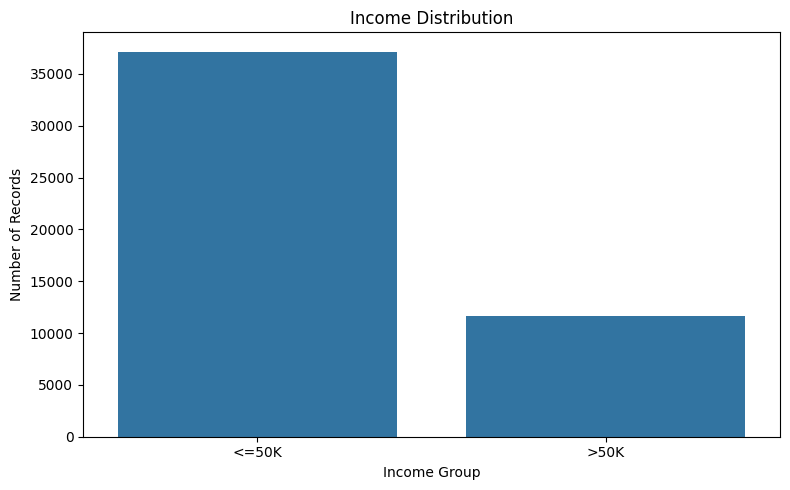

In [13]:
# plot income distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="income"
)

plt.title("Income Distribution")
plt.xlabel("Income Group")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

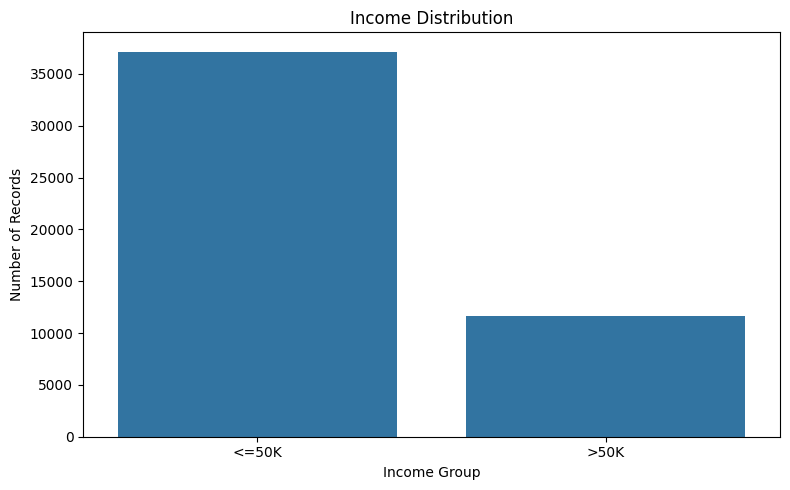

In [14]:
# save income distribution chart

income_chart_path = CHARTS_DIR / "income_distribution.png"

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="income"
)

plt.title("Income Distribution")
plt.xlabel("Income Group")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    income_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# display high income rate

print(f"Records above $50K: {df['high_income'].sum():,}")
print(f"Records at or below $50K: {(df['high_income'] == 0).sum():,}")
print(f"Above $50K rate: {df['high_income'].mean() * 100:.2f}%")

Records above $50K: 11,687
Records at or below $50K: 37,155
Above $50K rate: 23.93%


In [16]:
# calculate high income rate by education

education_summary = (
    df.groupby("education")["high_income"]
    .agg(
        total_records="count",
        high_income_count="sum",
        high_income_rate="mean"
    )
    .reset_index()
)

education_summary["high_income_rate"] = (
    education_summary["high_income_rate"] * 100
)

education_summary

,education,total_records,high_income_count,high_income_rate
0,10th,1389,87,6.263499
1,11th,1812,92,5.077263
2,12th,657,48,7.305936
3,1st-4th,247,8,3.238866
4,5th-6th,509,27,5.304519
5,7th-8th,955,62,6.492147
6,9th,756,41,5.423280
7,Assoc-acdm,1601,413,25.796377
8,Assoc-voc,2061,522,25.327511
9,Bachelors,8025,3313,41.283489


In [17]:
# sort education by high income rate

education_summary = education_summary.sort_values(
    "high_income_rate",
    ascending=False
)

education_summary

,education,total_records,high_income_count,high_income_rate
14,Prof-school,834,617,73.980815
10,Doctorate,594,431,72.558923
12,Masters,2657,1459,54.911554
9,Bachelors,8025,3313,41.283489
7,Assoc-acdm,1601,413,25.796377
8,Assoc-voc,2061,522,25.327511
15,Some-college,10878,2063,18.964883
11,HS-grad,15784,2503,15.857831
2,12th,657,48,7.305936
5,7th-8th,955,62,6.492147


In [18]:
# save education summary

education_summary_path = (
    TABLES_DIR / "education_income_summary.csv"
)

education_summary.to_csv(
    education_summary_path,
    index=False
)

print("Education summary saved successfully.")

Education summary saved successfully.


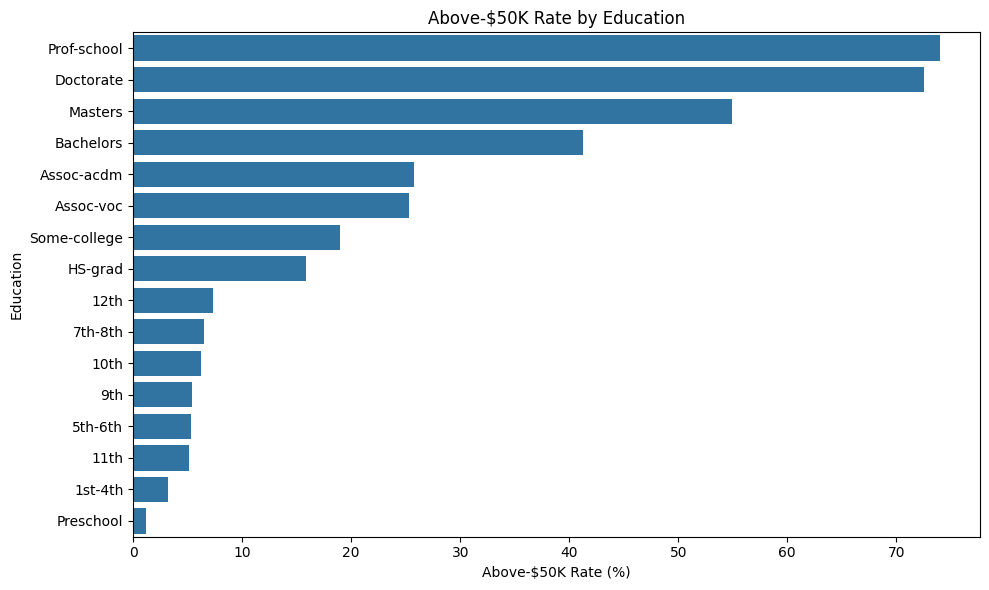

In [19]:
# plot high income rate by education

plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_summary,
    x="high_income_rate",
    y="education"
)

plt.title("Above-$50K Rate by Education")
plt.xlabel("Above-$50K Rate (%)")
plt.ylabel("Education")

plt.tight_layout()

plt.show()

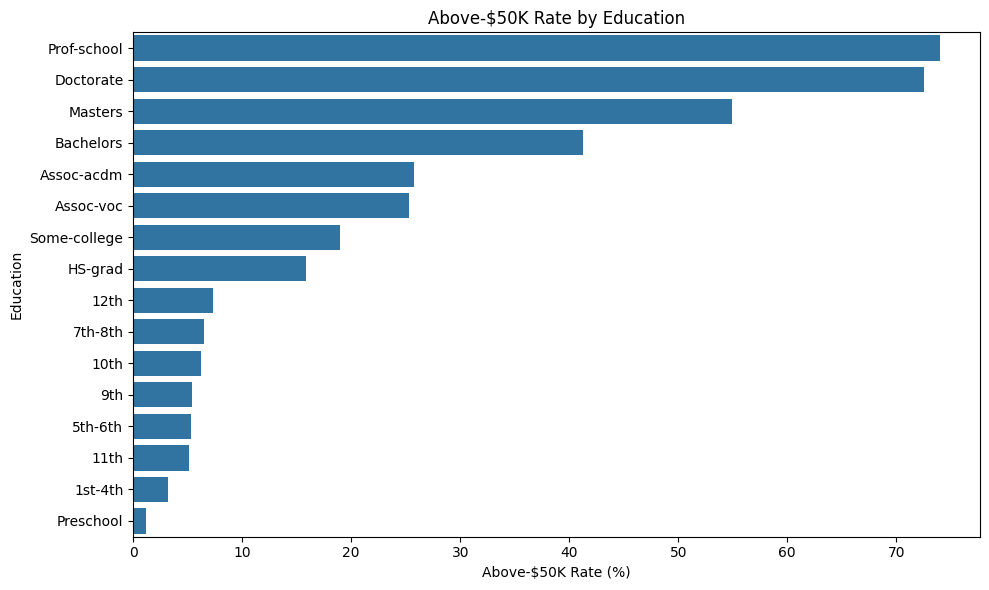

In [20]:
# save education income chart

education_chart_path = (
    CHARTS_DIR / "education_high_income_rate.png"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_summary,
    x="high_income_rate",
    y="education"
)

plt.title("Above-$50K Rate by Education")
plt.xlabel("Above-$50K Rate (%)")
plt.ylabel("Education")

plt.tight_layout()

plt.savefig(
    education_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# display education rates

print(
    education_summary[
        [
            "education",
            "total_records",
            "high_income_count",
            "high_income_rate"
        ]
    ].to_string(index=False)
)

   education  total_records  high_income_count  high_income_rate
 Prof-school            834                617         73.980815
   Doctorate            594                431         72.558923
     Masters           2657               1459         54.911554
   Bachelors           8025               3313         41.283489
  Assoc-acdm           1601                413         25.796377
   Assoc-voc           2061                522         25.327511
Some-college          10878               2063         18.964883
     HS-grad          15784               2503         15.857831
        12th            657                 48          7.305936
     7th-8th            955                 62          6.492147
        10th           1389                 87          6.263499
         9th            756                 41          5.423280
     5th-6th            509                 27          5.304519
        11th           1812                 92          5.077263
     1st-4th            2

In [22]:
# calculate high income rate by occupation

occupation_summary = (
    df.groupby("occupation")["high_income"]
    .agg(
        total_records="count",
        high_income_count="sum",
        high_income_rate="mean"
    )
    .reset_index()
)

occupation_summary["high_income_rate"] = (
    occupation_summary["high_income_rate"] * 100
)

occupation_summary

,occupation,total_records,high_income_count,high_income_rate
0,Adm-clerical,5611,768,13.687400
1,Armed-Forces,15,5,33.333333
2,Craft-repair,6112,1383,22.627618
3,Exec-managerial,6086,2908,47.781794
4,Farming-fishing,1490,173,11.610738
5,Handlers-cleaners,2072,138,6.660232
6,Machine-op-inspct,3022,372,12.309729
7,Other-service,4923,204,4.143815
8,Priv-house-serv,242,3,1.239669
9,Prof-specialty,6172,2784,45.106935


In [23]:
# sort occupation by high income rate

occupation_summary = occupation_summary.sort_values(
    "high_income_rate",
    ascending=False
)

occupation_summary

,occupation,total_records,high_income_count,high_income_rate
3,Exec-managerial,6086,2908,47.781794
9,Prof-specialty,6172,2784,45.106935
1,Armed-Forces,15,5,33.333333
10,Protective-serv,983,308,31.332655
12,Tech-support,1446,420,29.045643
11,Sales,5504,1475,26.798692
2,Craft-repair,6112,1383,22.627618
13,Transport-moving,2355,481,20.424628
0,Adm-clerical,5611,768,13.687400
6,Machine-op-inspct,3022,372,12.309729


In [24]:
# save occupation summary

occupation_summary_path = (
    TABLES_DIR / "occupation_income_summary.csv"
)

occupation_summary.to_csv(
    occupation_summary_path,
    index=False
)

print("Occupation summary saved successfully.")

Occupation summary saved successfully.


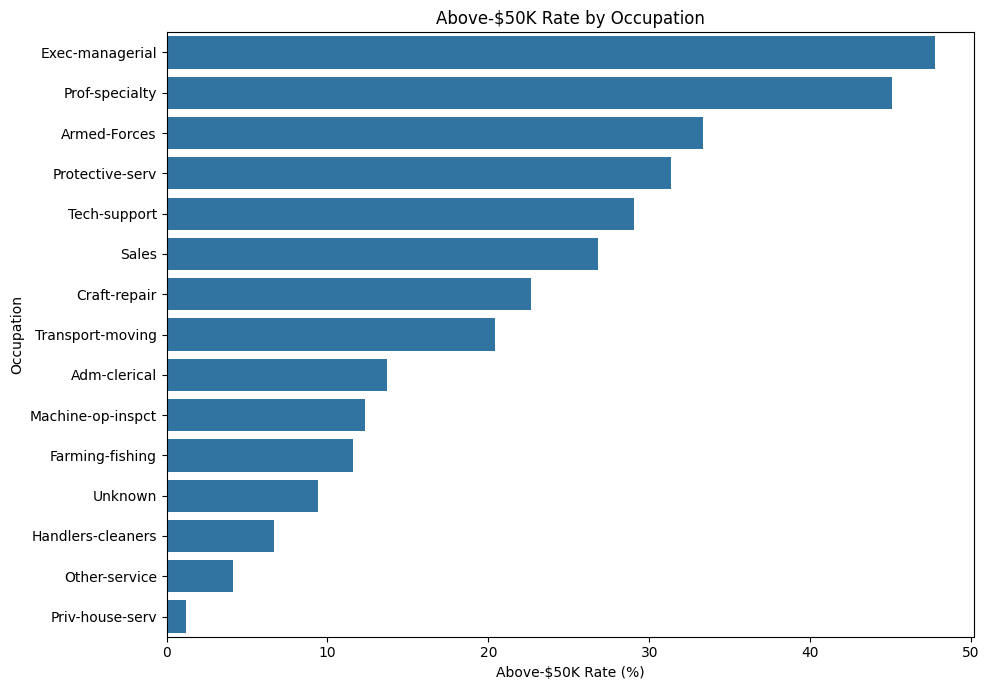

In [25]:
# plot high income rate by occupation

plt.figure(figsize=(10, 7))

sns.barplot(
    data=occupation_summary,
    x="high_income_rate",
    y="occupation"
)

plt.title("Above-$50K Rate by Occupation")
plt.xlabel("Above-$50K Rate (%)")
plt.ylabel("Occupation")

plt.tight_layout()

plt.show()

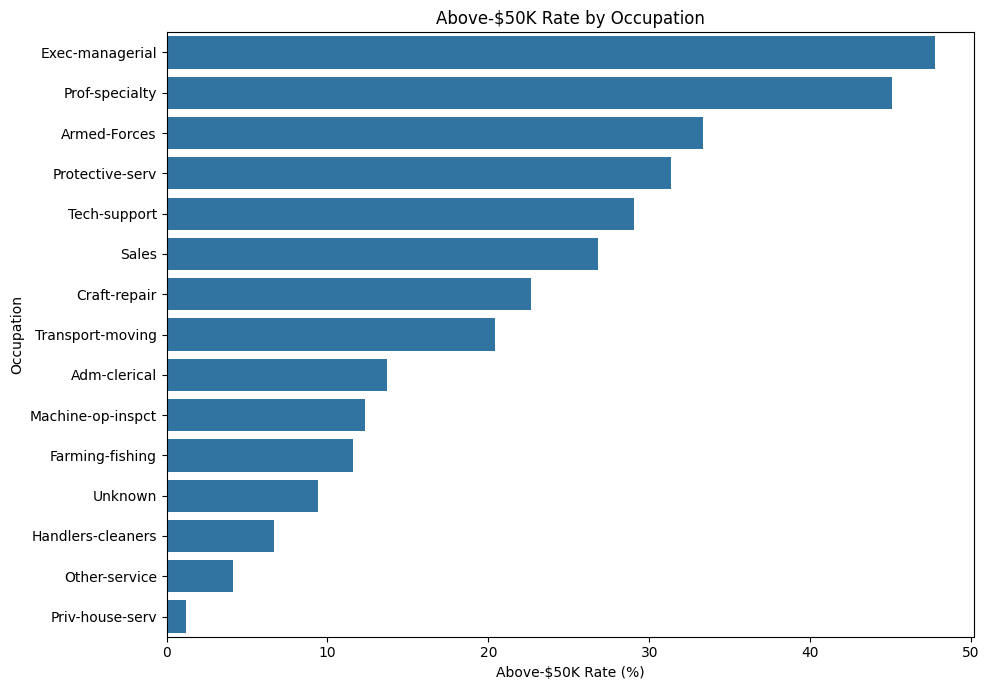

In [26]:
# save occupation income chart

occupation_chart_path = (
    CHARTS_DIR / "occupation_high_income_rate.png"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=occupation_summary,
    x="high_income_rate",
    y="occupation"
)

plt.title("Above-$50K Rate by Occupation")
plt.xlabel("Above-$50K Rate (%)")
plt.ylabel("Occupation")

plt.tight_layout()

plt.savefig(
    occupation_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# display occupation results

print(
    occupation_summary[
        [
            "occupation",
            "total_records",
            "high_income_count",
            "high_income_rate"
        ]
    ].to_string(index=False)
)

       occupation  total_records  high_income_count  high_income_rate
  Exec-managerial           6086               2908         47.781794
   Prof-specialty           6172               2784         45.106935
     Armed-Forces             15                  5         33.333333
  Protective-serv            983                308         31.332655
     Tech-support           1446                420         29.045643
            Sales           5504               1475         26.798692
     Craft-repair           6112               1383         22.627618
 Transport-moving           2355                481         20.424628
     Adm-clerical           5611                768         13.687400
Machine-op-inspct           3022                372         12.309729
  Farming-fishing           1490                173         11.610738
          Unknown           2809                265          9.433962
Handlers-cleaners           2072                138          6.660232
    Other-service   

In [28]:
# calculate high income rate by age group

age_group_summary = (
    df.groupby("age_group", observed=True)["high_income"]
    .agg(
        total_records="count",
        high_income_count="sum",
        high_income_rate="mean"
    )
    .reset_index()
)

age_group_summary["high_income_rate"] = (
    age_group_summary["high_income_rate"] * 100
)

age_group_summary

,age_group,total_records,high_income_count,high_income_rate
0,18-25,9627,169,1.755479
1,26-35,12719,2379,18.704301
2,36-45,11952,4131,34.563253
3,46-55,8296,3255,39.235776
4,56-65,4445,1396,31.406074
5,66+,1803,357,19.800333


In [29]:
# sort age groups in chronological order

age_order = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

age_group_summary["age_group"] = pd.Categorical(
    age_group_summary["age_group"],
    categories=age_order,
    ordered=True
)

age_group_summary = age_group_summary.sort_values(
    "age_group"
)

age_group_summary

,age_group,total_records,high_income_count,high_income_rate
0,18-25,9627,169,1.755479
1,26-35,12719,2379,18.704301
2,36-45,11952,4131,34.563253
3,46-55,8296,3255,39.235776
4,56-65,4445,1396,31.406074
5,66+,1803,357,19.800333


In [30]:
# save age group summary

age_group_summary_path = (
    TABLES_DIR / "age_group_income_summary.csv"
)

age_group_summary.to_csv(
    age_group_summary_path,
    index=False
)

print("Age group summary saved successfully.")

Age group summary saved successfully.


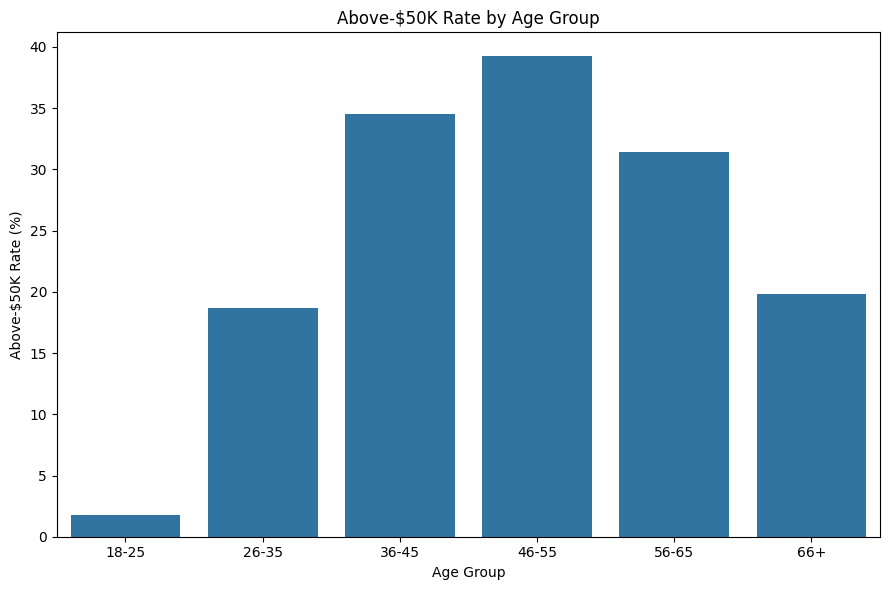

In [31]:
# plot high income rate by age group

plt.figure(figsize=(9, 6))

sns.barplot(
    data=age_group_summary,
    x="age_group",
    y="high_income_rate"
)

plt.title("Above-$50K Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Above-$50K Rate (%)")

plt.tight_layout()

plt.show()

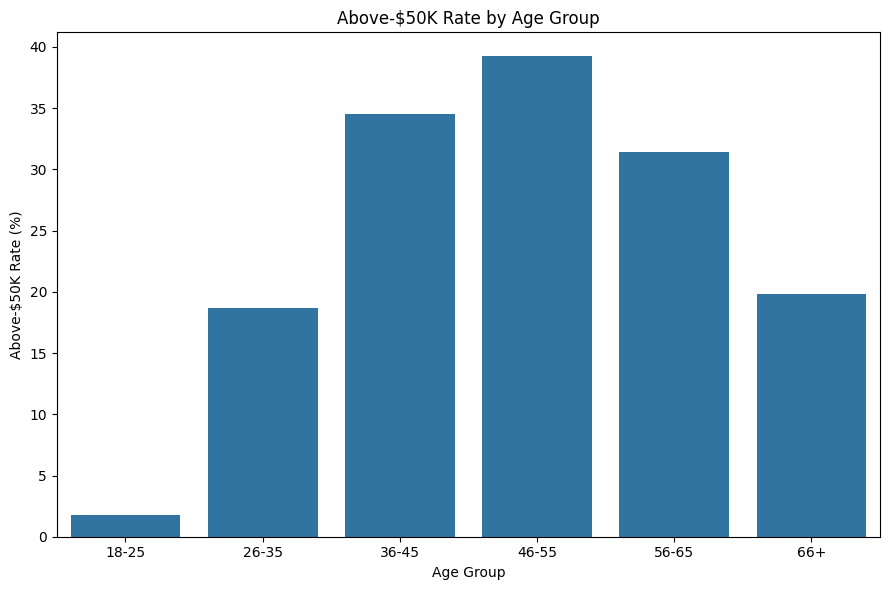

In [32]:
# save age group income chart

age_group_chart_path = (
    CHARTS_DIR / "age_group_high_income_rate.png"
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=age_group_summary,
    x="age_group",
    y="high_income_rate"
)

plt.title("Above-$50K Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Above-$50K Rate (%)")

plt.tight_layout()

plt.savefig(
    age_group_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# display age group results

print(
    age_group_summary[
        [
            "age_group",
            "total_records",
            "high_income_count",
            "high_income_rate"
        ]
    ].to_string(index=False)
)

age_group  total_records  high_income_count  high_income_rate
    18-25           9627                169          1.755479
    26-35          12719               2379         18.704301
    36-45          11952               4131         34.563253
    46-55           8296               3255         39.235776
    56-65           4445               1396         31.406074
      66+           1803                357         19.800333


In [34]:
# calculate high income rate by workclass

workclass_summary = (
    df.groupby("workclass")["high_income"]
    .agg(
        total_records="count",
        high_income_count="sum",
        high_income_rate="mean"
    )
    .reset_index()
)

workclass_summary["high_income_rate"] = (
    workclass_summary["high_income_rate"] * 100
)

workclass_summary

,workclass,total_records,high_income_count,high_income_rate
0,Federal-gov,1432,561,39.175978
1,Local-gov,3136,927,29.559949
2,Never-worked,10,0,0.000000
3,Private,33906,7387,21.786704
4,Self-emp-inc,1695,938,55.339233
5,Self-emp-not-inc,3862,1077,27.887105
6,State-gov,1981,530,26.754165
7,Unknown,2799,265,9.467667
8,Without-pay,21,2,9.523810


In [35]:
# sort workclass by high income rate

workclass_summary = workclass_summary.sort_values(
    "high_income_rate",
    ascending=False
)

workclass_summary

,workclass,total_records,high_income_count,high_income_rate
4,Self-emp-inc,1695,938,55.339233
0,Federal-gov,1432,561,39.175978
1,Local-gov,3136,927,29.559949
5,Self-emp-not-inc,3862,1077,27.887105
6,State-gov,1981,530,26.754165
3,Private,33906,7387,21.786704
8,Without-pay,21,2,9.523810
7,Unknown,2799,265,9.467667
2,Never-worked,10,0,0.000000


In [36]:
# save workclass summary

workclass_summary_path = (
    TABLES_DIR / "workclass_income_summary.csv"
)

workclass_summary.to_csv(
    workclass_summary_path,
    index=False
)

print("Workclass summary saved successfully.")

Workclass summary saved successfully.


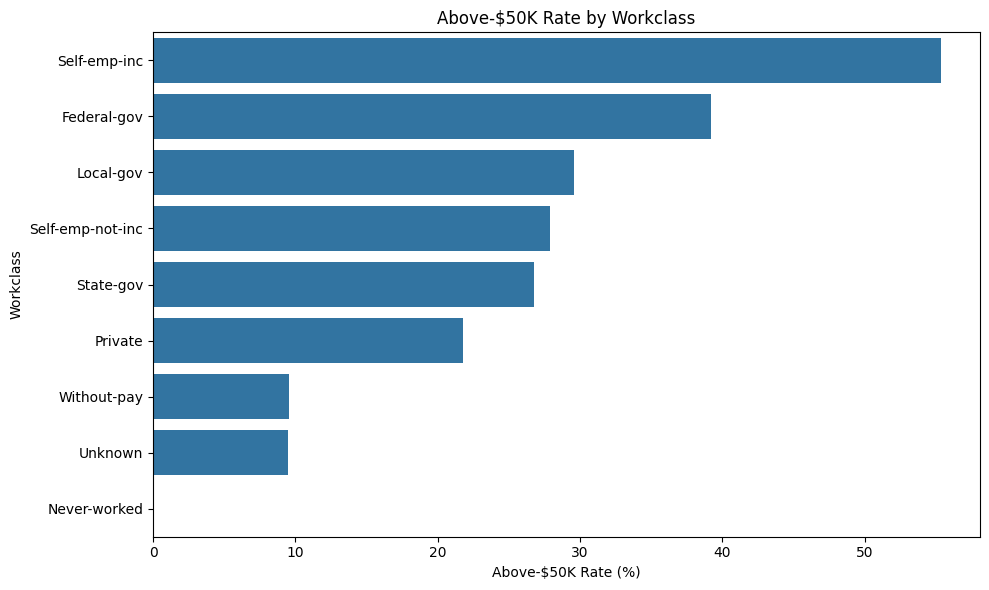

In [37]:
# plot high income rate by workclass

plt.figure(figsize=(10, 6))

sns.barplot(
    data=workclass_summary,
    x="high_income_rate",
    y="workclass"
)

plt.title("Above-$50K Rate by Workclass")
plt.xlabel("Above-$50K Rate (%)")
plt.ylabel("Workclass")

plt.tight_layout()

plt.show()

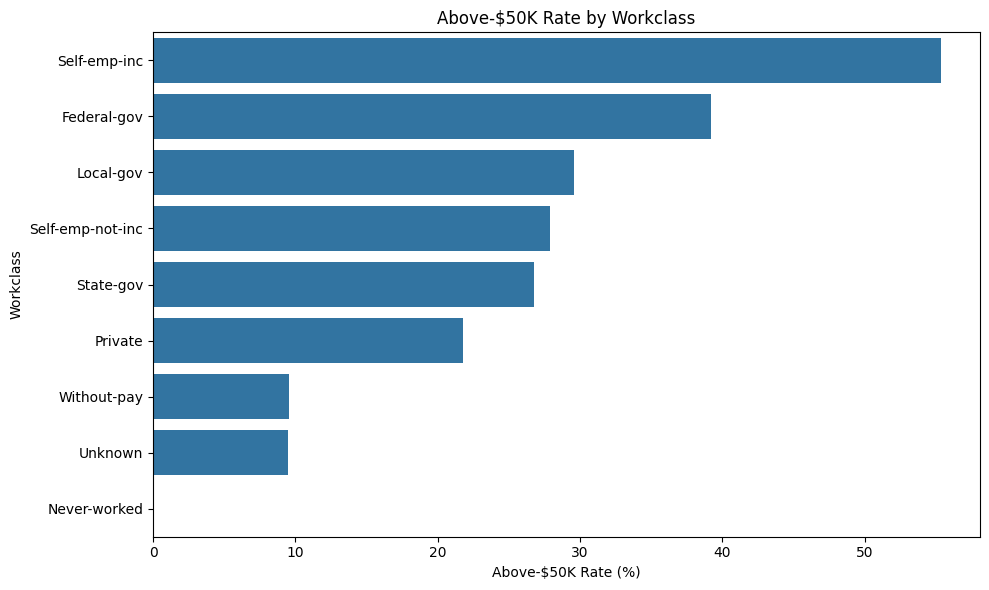

In [38]:
# save workclass income chart

workclass_chart_path = (
    CHARTS_DIR / "workclass_high_income_rate.png"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=workclass_summary,
    x="high_income_rate",
    y="workclass"
)

plt.title("Above-$50K Rate by Workclass")
plt.xlabel("Above-$50K Rate (%)")
plt.ylabel("Workclass")

plt.tight_layout()

plt.savefig(
    workclass_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# display workclass results

print(
    workclass_summary[
        [
            "workclass",
            "total_records",
            "high_income_count",
            "high_income_rate"
        ]
    ].to_string(index=False)
)

       workclass  total_records  high_income_count  high_income_rate
    Self-emp-inc           1695                938         55.339233
     Federal-gov           1432                561         39.175978
       Local-gov           3136                927         29.559949
Self-emp-not-inc           3862               1077         27.887105
       State-gov           1981                530         26.754165
         Private          33906               7387         21.786704
     Without-pay             21                  2          9.523810
         Unknown           2799                265          9.467667
    Never-worked             10                  0          0.000000


In [40]:
# calculate high income rate by sex

sex_summary = (
    df.groupby("sex")["high_income"]
    .agg(
        total_records="count",
        high_income_count="sum",
        high_income_rate="mean"
    )
    .reset_index()
)

sex_summary["high_income_rate"] = (
    sex_summary["high_income_rate"] * 100
)

sex_summary

,sex,total_records,high_income_count,high_income_rate
0,Female,16192,1769,10.925148
1,Male,32650,9918,30.376723


In [41]:
# sort sex by high income rate

sex_summary = sex_summary.sort_values(
    "high_income_rate",
    ascending=False
)

sex_summary

,sex,total_records,high_income_count,high_income_rate
1,Male,32650,9918,30.376723
0,Female,16192,1769,10.925148


In [42]:
# save sex summary

sex_summary_path = (
    TABLES_DIR / "sex_income_summary.csv"
)

sex_summary.to_csv(
    sex_summary_path,
    index=False
)

print("Sex summary saved successfully.")

Sex summary saved successfully.


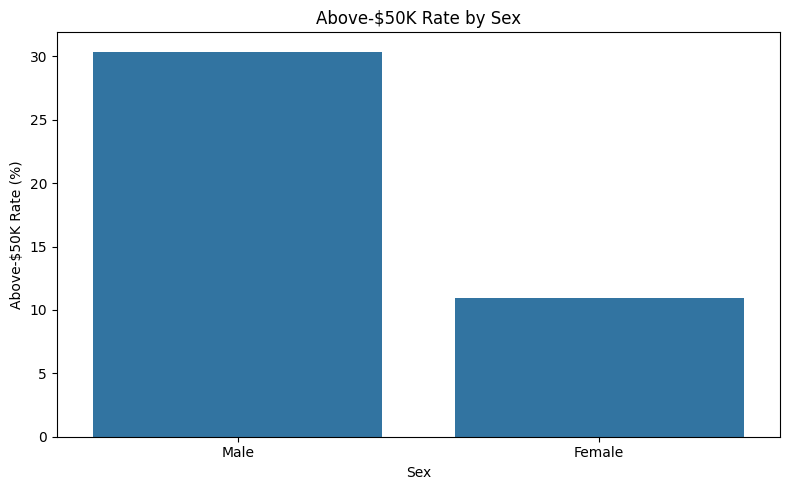

In [43]:
# plot high income rate by sex

plt.figure(figsize=(8, 5))

sns.barplot(
    data=sex_summary,
    x="sex",
    y="high_income_rate"
)

plt.title("Above-$50K Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Above-$50K Rate (%)")

plt.tight_layout()

plt.show()

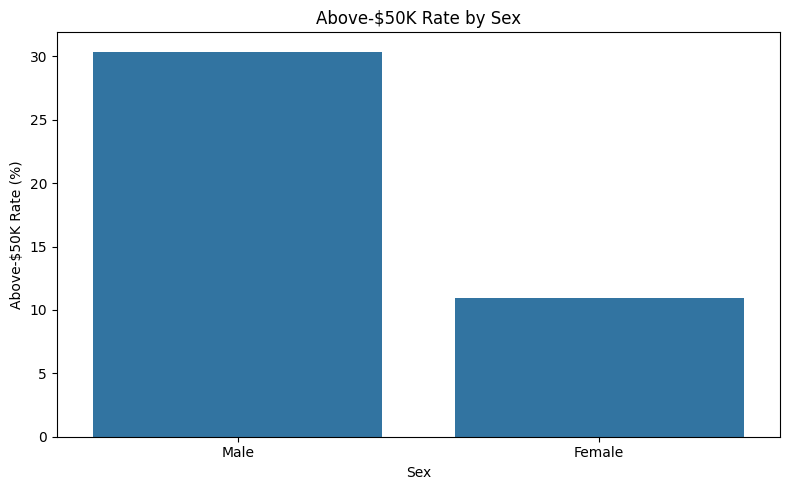

In [44]:
# save sex income chart

sex_chart_path = (
    CHARTS_DIR / "sex_high_income_rate.png"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=sex_summary,
    x="sex",
    y="high_income_rate"
)

plt.title("Above-$50K Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Above-$50K Rate (%)")

plt.tight_layout()

plt.savefig(
    sex_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# display sex results

print(
    sex_summary[
        [
            "sex",
            "total_records",
            "high_income_count",
            "high_income_rate"
        ]
    ].to_string(index=False)
)

   sex  total_records  high_income_count  high_income_rate
  Male          32650               9918         30.376723
Female          16192               1769         10.925148


In [46]:
# check working hours by income group

hours_summary = (
    df.groupby("income")["hours_per_week"]
    .describe()
)

hours_summary

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,37155.0,38.840048,12.356849,1.0,35.0,40.0,40.0,99.0
>50K,11687.0,45.452896,11.091176,1.0,40.0,40.0,50.0,99.0


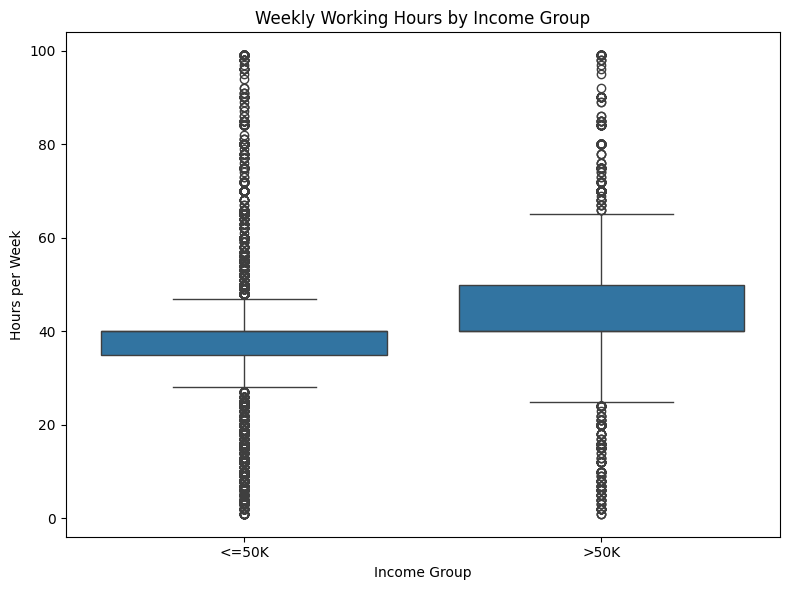

In [47]:
# plot weekly working hours by income group

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week"
)

plt.title("Weekly Working Hours by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Hours per Week")

plt.tight_layout()

plt.show()

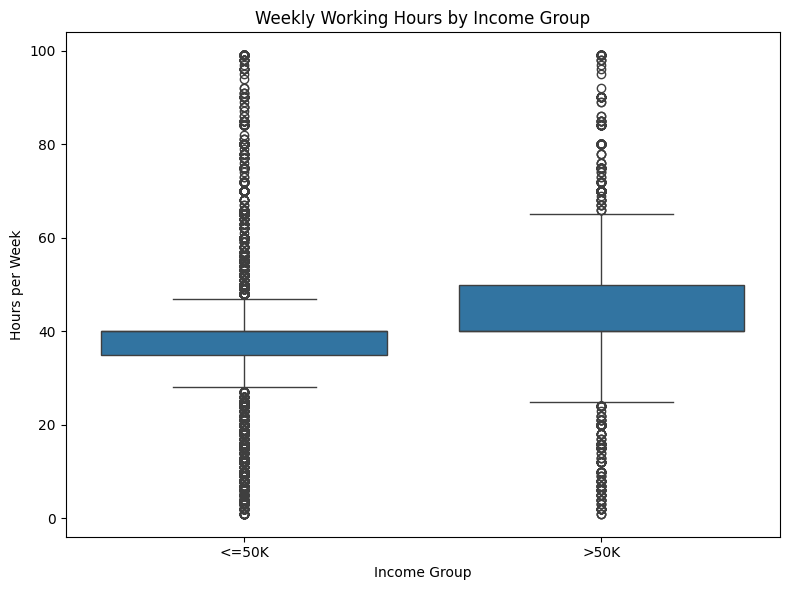

In [48]:
# save weekly hours box plot

hours_boxplot_path = (
    CHARTS_DIR / "weekly_hours_by_income.png"
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week"
)

plt.title("Weekly Working Hours by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Hours per Week")

plt.tight_layout()

plt.savefig(
    hours_boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

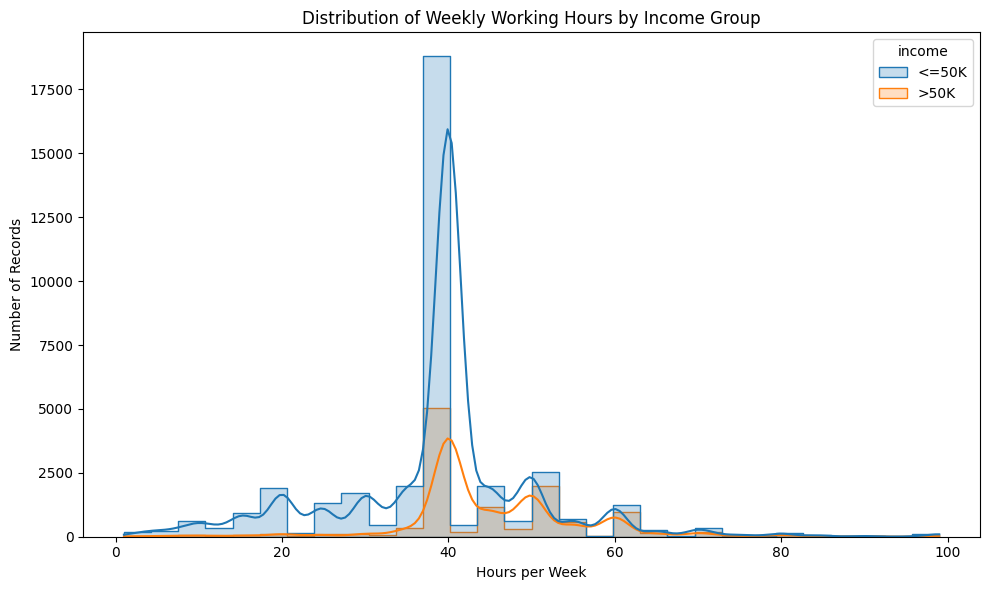

In [49]:
# plot weekly working hours distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="hours_per_week",
    hue="income",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Weekly Working Hours by Income Group")
plt.xlabel("Hours per Week")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

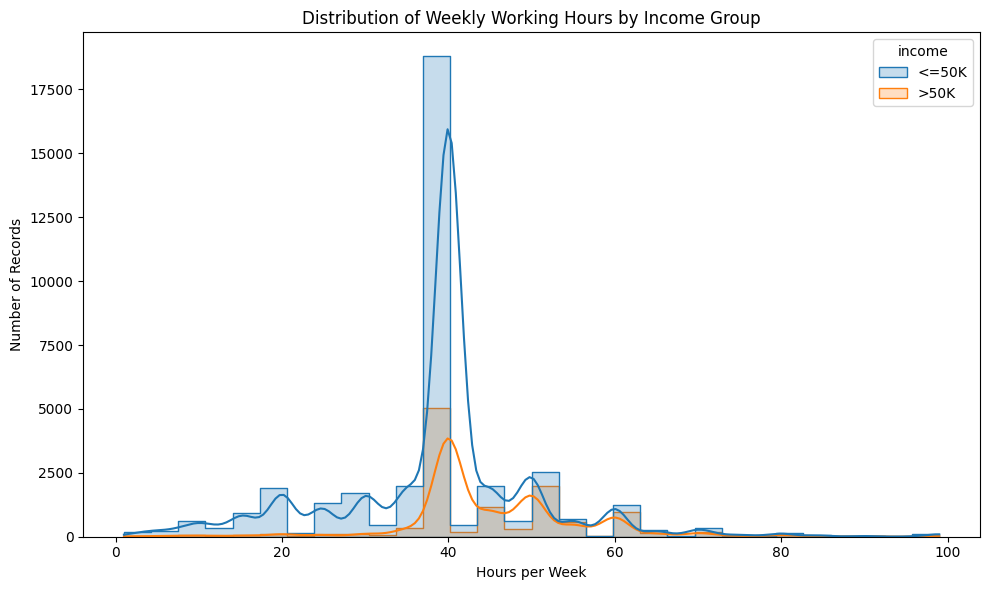

In [50]:
# save weekly hours distribution chart

hours_distribution_path = (
    CHARTS_DIR / "weekly_hours_distribution.png"
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="hours_per_week",
    hue="income",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Weekly Working Hours by Income Group")
plt.xlabel("Hours per Week")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    hours_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# save weekly hours summary

hours_summary_path = (
    TABLES_DIR / "weekly_hours_summary.csv"
)

hours_summary.to_csv(
    hours_summary_path
)

print("Weekly hours summary saved successfully.")

Weekly hours summary saved successfully.


In [52]:
# select numeric columns for correlation analysis

numeric_eda_columns = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "net_capital",
    "high_income"
]

numeric_eda = df[numeric_eda_columns]

numeric_eda.head()

,age,education_num,hours_per_week,capital_gain,capital_loss,net_capital,high_income
0,39,13,40,2174,0,2174,0
1,50,13,13,0,0,0,0
2,38,9,40,0,0,0,0
3,53,7,40,0,0,0,0
4,28,13,40,0,0,0,0


In [53]:
# calculate numeric correlations

correlation_matrix = numeric_eda.corr()

correlation_matrix

,age,education_num,hours_per_week,capital_gain,capital_loss,net_capital,high_income
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.073916,0.230369
education_num,0.030940,1.000000,0.143689,0.125146,0.080972,0.120387,0.332613
hours_per_week,0.071558,0.143689,1.000000,0.082157,0.054467,0.078962,0.227687
capital_gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.998547,0.223013
capital_loss,0.056944,0.080972,0.054467,-0.031441,1.000000,-0.085251,0.147554
net_capital,0.073916,0.120387,0.078962,0.998547,-0.085251,1.000000,0.214356
high_income,0.230369,0.332613,0.227687,0.223013,0.147554,0.214356,1.000000


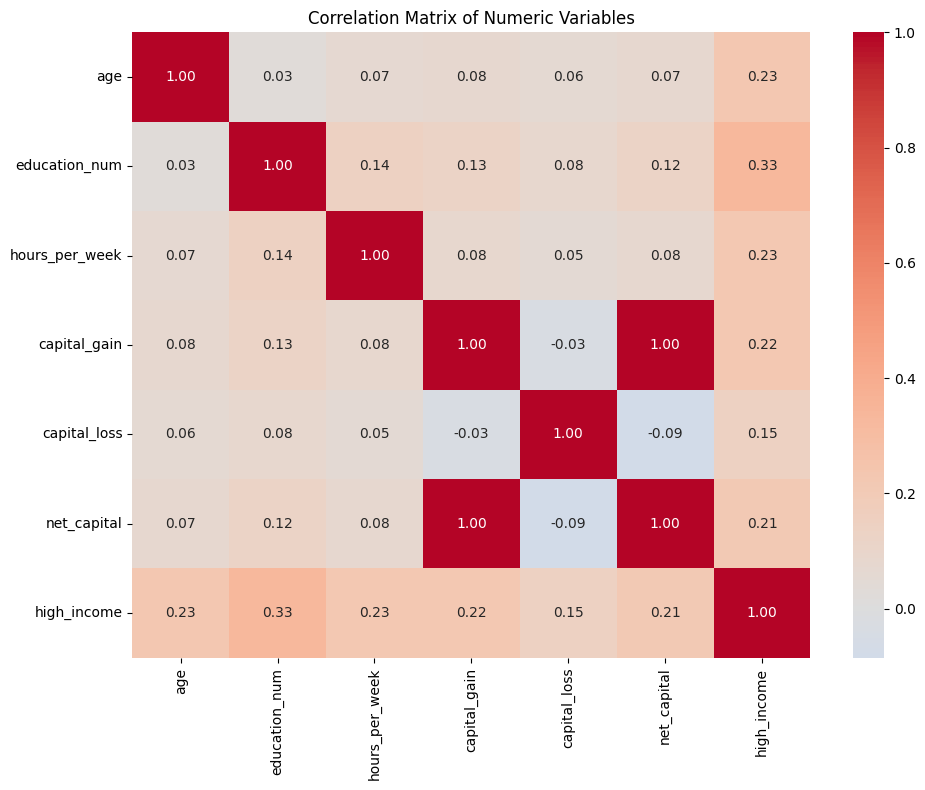

In [54]:
# plot correlation heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Variables")

plt.tight_layout()

plt.show()

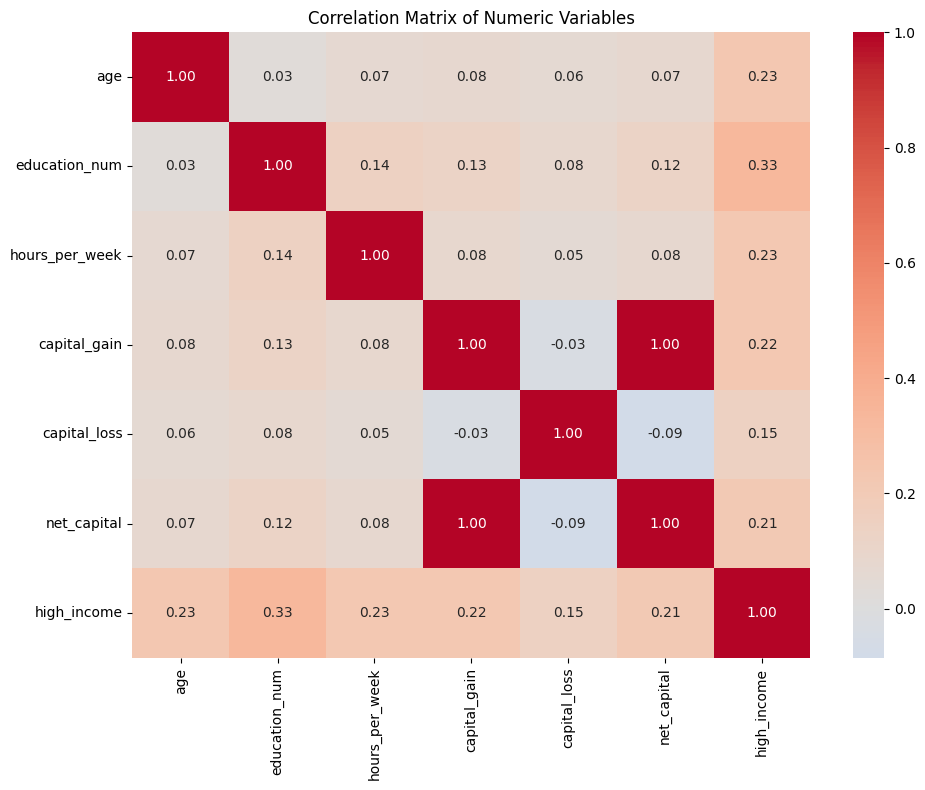

In [55]:
# save correlation heatmap

correlation_chart_path = (
    CHARTS_DIR / "numeric_correlation_heatmap.png"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Variables")

plt.tight_layout()

plt.savefig(
    correlation_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# save correlation matrix

correlation_table_path = (
    TABLES_DIR / "numeric_correlation_matrix.csv"
)

correlation_matrix.to_csv(
    correlation_table_path
)

print("Correlation matrix saved successfully.")

Correlation matrix saved successfully.


In [57]:
# check numeric distributions

df[
    [
        "age",
        "education_num",
        "hours_per_week",
        "capital_gain",
        "capital_loss",
        "net_capital"
    ]
].describe()

,age,education_num,hours_per_week,capital_gain,capital_loss,net_capital
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,40.422382,1079.067626,87.502314,991.565313
std,13.710510,2.570973,12.391444,7452.019058,403.004552,7475.549906
min,17.000000,1.000000,1.000000,0.000000,0.000000,-4356.000000
25%,28.000000,9.000000,40.000000,0.000000,0.000000,0.000000
50%,37.000000,10.000000,40.000000,0.000000,0.000000,0.000000
75%,48.000000,12.000000,45.000000,0.000000,0.000000,0.000000
max,90.000000,16.000000,99.000000,99999.000000,4356.000000,99999.000000


In [58]:
# check zero values in capital gain and loss

print("Capital gain zero values:", (df["capital_gain"] == 0).sum())
print("Capital loss zero values:", (df["capital_loss"] == 0).sum())

Capital gain zero values: 44807
Capital loss zero values: 46560


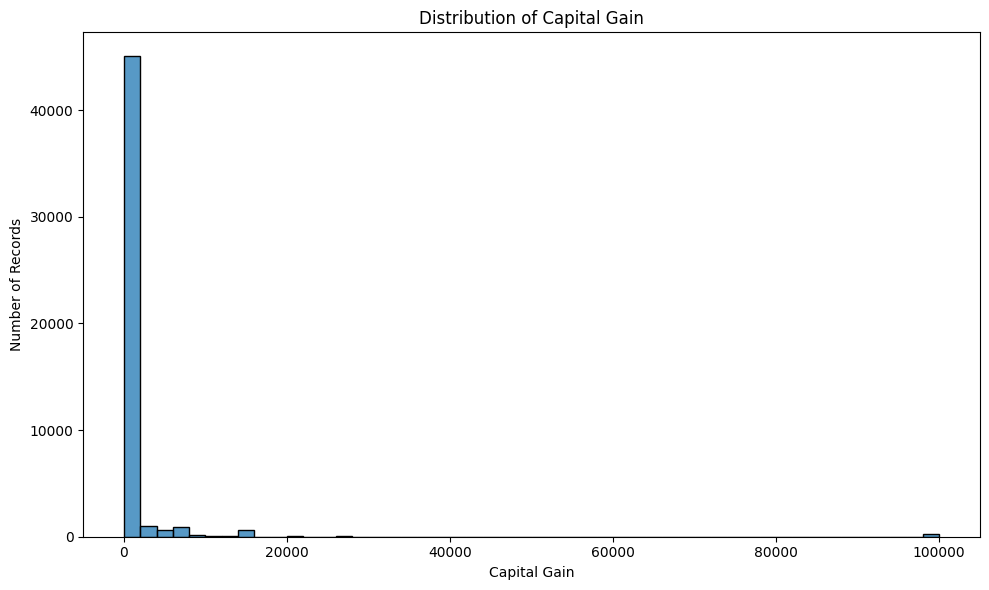

In [59]:
# plot capital gain distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="capital_gain",
    bins=50
)

plt.title("Distribution of Capital Gain")
plt.xlabel("Capital Gain")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

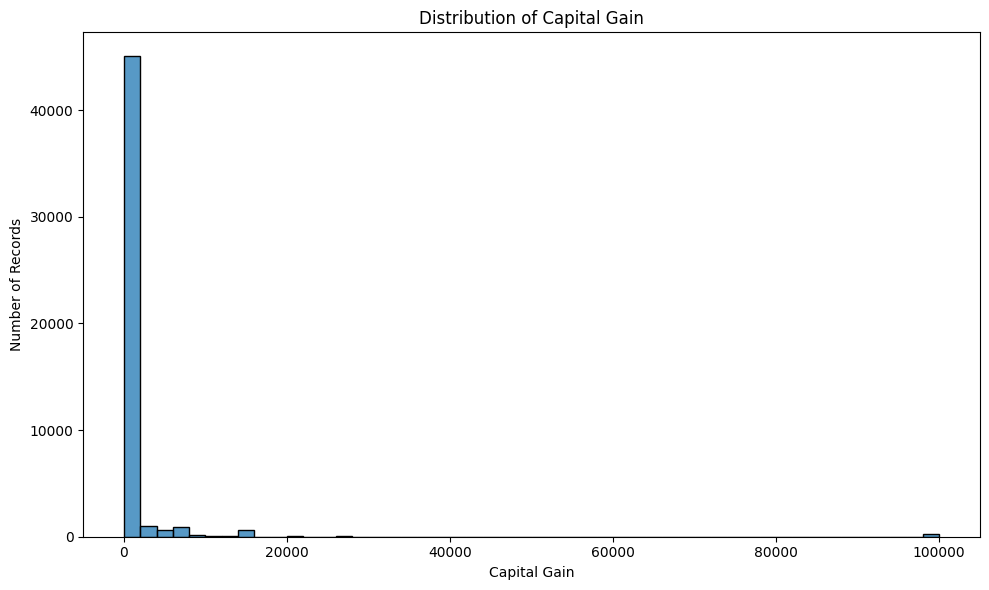

In [60]:
# save capital gain distribution chart

capital_gain_chart_path = (
    CHARTS_DIR / "capital_gain_distribution.png"
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="capital_gain",
    bins=50
)

plt.title("Distribution of Capital Gain")
plt.xlabel("Capital Gain")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    capital_gain_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

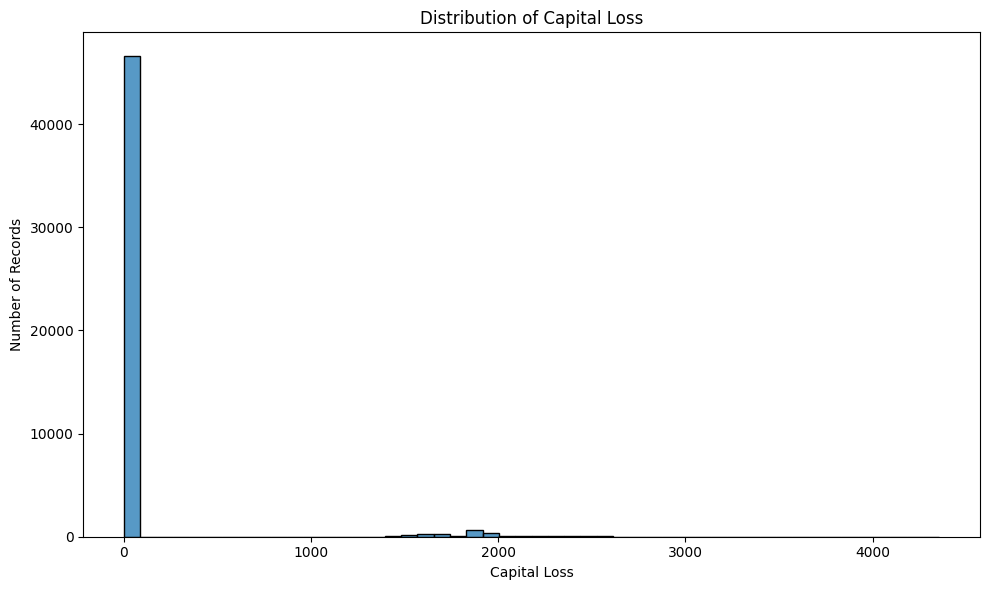

In [61]:
# plot capital loss distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="capital_loss",
    bins=50
)

plt.title("Distribution of Capital Loss")
plt.xlabel("Capital Loss")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

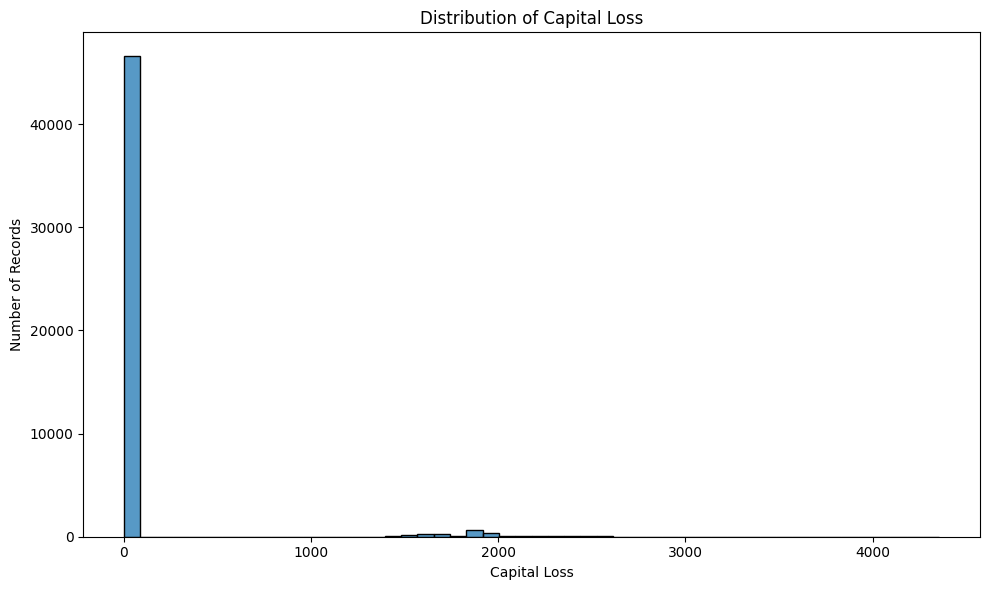

In [62]:
# save capital loss distribution chart

capital_loss_chart_path = (
    CHARTS_DIR / "capital_loss_distribution.png"
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="capital_loss",
    bins=50
)

plt.title("Distribution of Capital Loss")
plt.xlabel("Capital Loss")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    capital_loss_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# create numeric summary

numeric_summary = df[
    [
        "age",
        "education_num",
        "hours_per_week",
        "capital_gain",
        "capital_loss",
        "net_capital"
    ]
].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
education_num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
hours_per_week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0
capital_gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital_loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
net_capital,48842.0,991.565313,7475.549906,-4356.0,0.0,0.0,0.0,99999.0


In [64]:
# save numeric summary

numeric_summary_path = (
    TABLES_DIR / "numeric_summary.csv"
)

numeric_summary.to_csv(
    numeric_summary_path
)

print("Numeric summary saved successfully.")

Numeric summary saved successfully.


# Key Findings

## 1. Overall Income Distribution

The dataset contains 48,842 records. Among these, 11,687 records have an
income above USD 50K, while 37,155 records have an income at or below USD 50K.
Therefore, 23.93% of the records belong to the above-USD-50K income group.

## 2. Education

The above-USD-50K rate varies across education categories. The calculated
rates show that income distribution is not the same across education groups.

## 3. Occupation

The above-USD-50K rate also varies across occupation categories. Occupation
groups have different proportions of records above USD 50K.

## 4. Age Group

The above-USD-50K rate varies across age groups. The observed rates are
different for younger, middle-aged, and older groups.

## 5. Workclass

The above-USD-50K rate differs across workclass categories. The results
show variation between government, private, self-employment, and other
workclass categories.

## 6. Sex

The above-USD-50K rate differs between the sex categories in this dataset.
The calculated rate for males is 30.38%, while the calculated rate for
females is 10.93%.

## 7. Weekly Working Hours

The above-USD-50K group has a higher average weekly working time than the
at-or-below-USD-50K group. The mean is 45.45 hours for the above-USD-50K
group and 38.84 hours for the at-or-below-USD-50K group.

Both groups have a median of 40 hours per week.

## 8. Numeric Relationships

The correlation analysis shows different levels of linear association
between the numeric variables and the high-income indicator.

Among the examined numeric variables, education_num has the highest
correlation with high_income at approximately 0.33.

Age and hours_per_week each have a correlation of approximately 0.23
with high_income.

Capital gain has a correlation of approximately 0.22, net capital has
approximately 0.21, and capital loss has approximately 0.15.

These correlations describe associations and do not establish causation.

# Limitations

1. Historical Dataset

The Adult dataset represents historical census information. The patterns
observed in this dataset may not represent current income patterns.

2. Observational Analysis

This project is descriptive. The analysis identifies associations between
variables and income groups but does not prove that one variable causes
another.

3. Demographic Variables

The dataset contains demographic characteristics such as age, sex, and race.
Differences observed across these groups should be interpreted as descriptive
patterns in the dataset and not as evidence of individual-level outcomes.

4. Missing Values

The original UCI data uses `?` to represent missing categorical values.
These values were converted to `Unknown` for selected categorical columns
instead of deleting the corresponding records.

5. Duplicate Records

Exact duplicate rows were audited but retained because the dataset does not
contain a unique person identifier. Identical rows cannot automatically be
assumed to represent the same person.

6. Unweighted Visual Summaries

The EDA uses the records directly for tables and visualizations. The
`fnlwgt` census weight was not applied to produce weighted population
estimates.

7. Correlation Limitations

Correlation measures linear association and does not establish causation.
A low correlation does not necessarily mean that a relationship is absent.

8. Income Threshold

The target variable is based on the dataset's `<=50K` and `>50K` categories.
The analysis therefore describes this specific threshold rather than income
as a continuous variable.

9. No Predictive Modeling

This project focuses on data cleaning and descriptive EDA. The results should
not be interpreted as a predictive model or as evidence of predictive
performance.

# Conclusion

This project combined the official UCI Adult dataset partitions, cleaned the
data, handled missing categorical values, normalized the income labels, and
created additional features for exploratory analysis.

The analysis found differences in the proportion of records above USD 50K
across education, occupation, age group, workclass, and sex categories.
Weekly working-hour patterns also differed between the two income groups.

The numeric analysis showed varying levels of association between the
high-income indicator and variables such as education level, age, working
hours, and capital-related variables.

Overall, the project demonstrates a complete data-analysis workflow:

data collection → data cleaning → validation → feature engineering →
exploratory analysis → visualization → interpretation → documentation.

The findings describe patterns and associations within this historical
dataset. They should not be interpreted as causal relationships or as
representative estimates of the current population.